# Regression Trees

* In this exercise, we will explore training, visualizing, and pruning Decision Trees for regression tasks.
* This exercise is based on the `Hitters` dataset discussed in Sec. 8.1 of the ISLP textbook (see page 331).
* The `Hitters` dataset, provided as a `.csv` file contains information about several baseball players

Let's begin by importing
1. The standard libraries: Pandas, Numpy, Pyplot, and Seaborn.
2. From Scikit-Learn: `train_test_split`, `DecisionTreeRegressor`, and `mean_squared_error`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

Set your Pyplot style to `seaborn-v0_8-bright`

In [2]:
plt.style.use('seaborn-v0_8-bright')

* Read the CSV file into a Pandas DataFrame named `df`
* How many features does the dataset have in total (do not count the `Salary` column here!)? How did you find this information?
* How many datapoints does this dataset have in total?
* How many features have missing entries? How did you find this?

In [3]:
df = pd.read_csv("C:/Users/kevMi/OneDrive/Documents/csFiles-BU/BostonUniversityCS/CS677-BU/HW6_upload/upload/DATA/Hitters.csv")
df1 = df.drop(columns='Salary')
print(f"Number of features: {df1.shape[1]}")
num_datapoints = df1.shape[0]
print(f"Number of datapoints: {num_datapoints}")
num_missing_features = df.isnull().any().sum()
print(f"Number of features with missing values: {num_missing_features}")


Number of features: 20
Number of datapoints: 322
Number of features with missing values: 1


* Set `X` to be the features (we only require the `Years` and `Hits` features here).
* As noted in Sec. 8.1 we set as our regression label the $\log()$ of the salary.
* Reproduce the histograms of `salary` and $\log(salary)$ as shown below.
    * As you can see, computing the logarithm also helps reduce skewness in the `salary` column and the resulting histogram (after transformation) looks closer to a Gaussian.

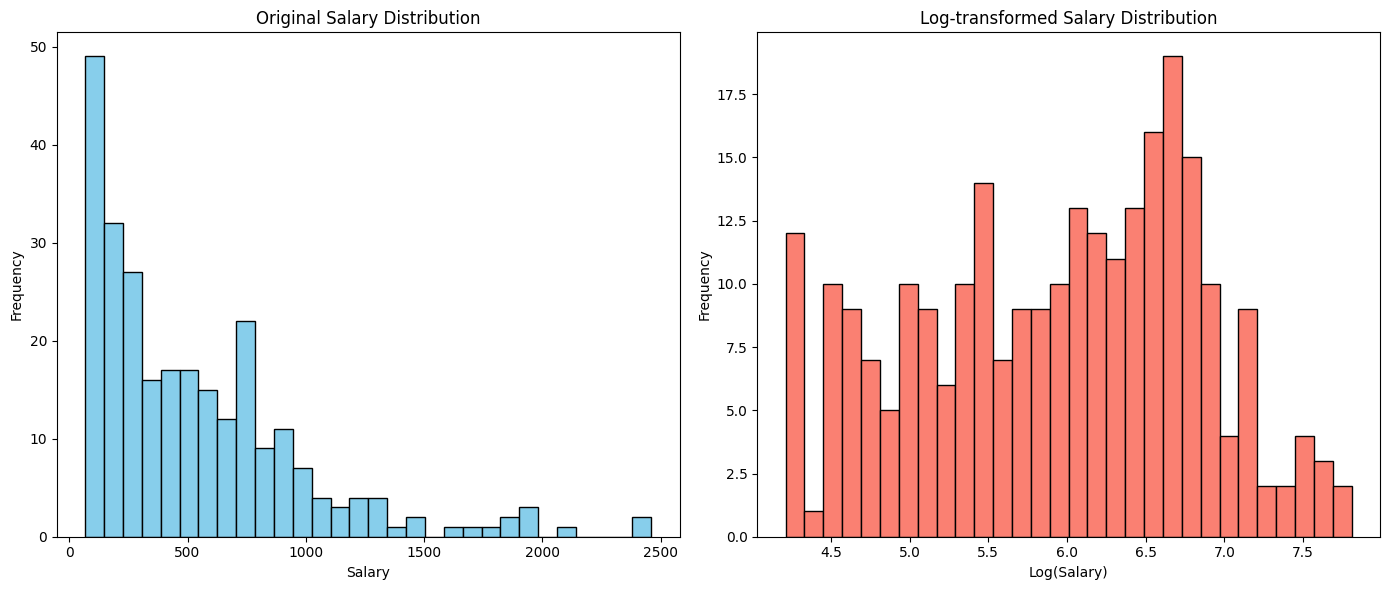

In [18]:
X = df[['Years', 'Hits']]

df['log_salary'] = np.log(df['Salary'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for original salary
axes[0].hist(df['Salary'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Original Salary Distribution')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

# Histogram for log-transformed salary
axes[1].hist(df['log_salary'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Log-transformed Salary Distribution')
axes[1].set_xlabel('Log(Salary)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

* Fit a tree to all the available data. The tree should have a maximum of `5` leaf nodes (set `random_state=42` for reproducibility).

In [19]:
# Drop rows with missing log_salary values to avoid errors
df_clean = df.dropna(subset=['log_salary'])
X_clean = df_clean[['Years', 'Hits']]
y_clean = df_clean['log_salary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Initialize the DecisionTreeRegressor with max_leaf_nodes=5 and random_state=42 for reproducibility
tree_regressor = DecisionTreeRegressor(max_leaf_nodes=5, random_state=42)

# Fit the model to the training data
tree_regressor.fit(X_train, y_train)

# Optionally, evaluate the model on the test data (e.g., using R^2 score)
r2_score = tree_regressor.score(X_test, y_test)

print(f"R^2 score on the test set: {r2_score:.4f}")

R^2 score on the test set: 0.6781


* Using the `export_graphiviz` command, draw the resulting fitted tree (it should look as shown below).
* Information about `export_graphiviz` is available in Chapter 6 of the course textbook (see Fig. 6-1).

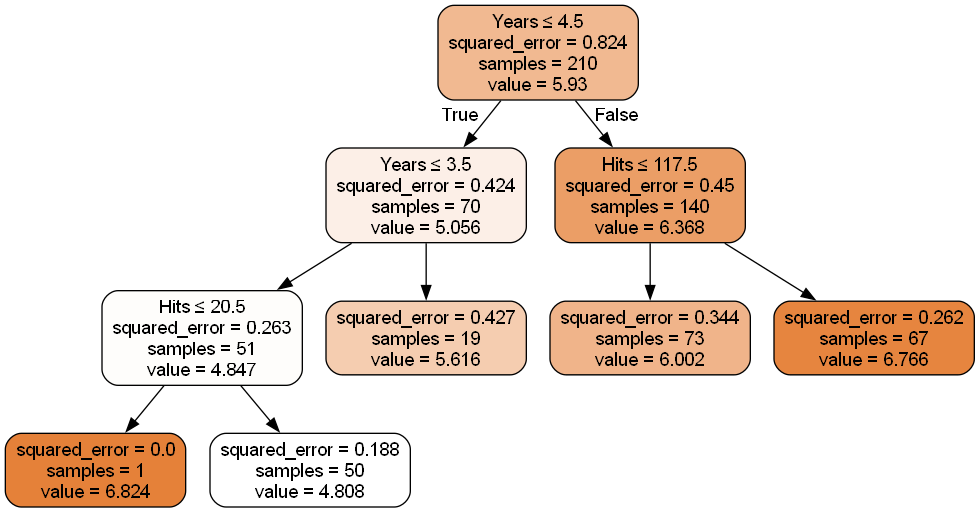

In [20]:
import os
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import Image
# Export the tree as DOT data
dot_data = export_graphviz(tree_regressor, 
                           out_file=None, 
                           feature_names=['Years', 'Hits'], 
                           filled=True, 
                           rounded=True, 
                           special_characters=True)

# Create Graphviz Source object
graph = graphviz.Source(dot_data)

# Save the decision tree as a PNG and clean up the .dot file
graph.render("decision_tree", format='png', cleanup=True)

# Display the image in the notebook
Image(filename="decision_tree.png")


* In Pyplot, generate the resulting decision regions.
* Compare the number of `samples` in each leaf node in your fitted tree with the number of data points in each decision region in your plot.

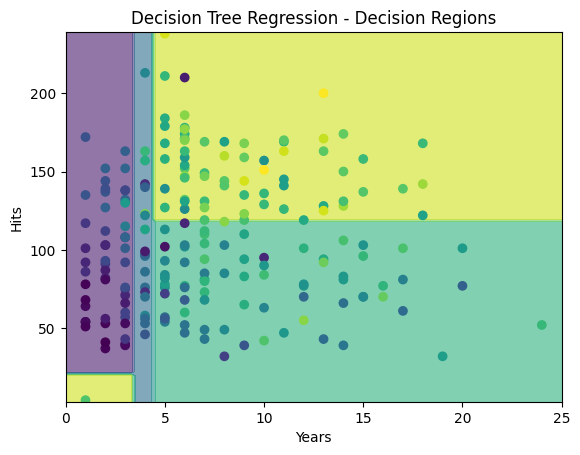

Samples in each leaf node (from tree):
Leaf 8: 50 samples
Leaf 4: 67 samples
Leaf 3: 73 samples
Leaf 6: 19 samples
Leaf 7: 1 samples


In [21]:
from sklearn.inspection import DecisionBoundaryDisplay
# Plot the decision regions using the fitted tree
disp = DecisionBoundaryDisplay.from_estimator(
    tree_regressor, X_train,
    response_method="predict",
    alpha=0.6
)

# Overlay the actual training points
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train)
plt.xlabel('Years')
plt.ylabel('Hits')
plt.title('Decision Tree Regression - Decision Regions')

plt.show()
# Get predictions for all training samples
leaf_indices = tree_regressor.apply(X_train)

# Count samples in each leaf node
import collections
leaf_counts = collections.Counter(leaf_indices)

print("Samples in each leaf node (from tree):")
for leaf_id, count in leaf_counts.items():
    print(f"Leaf {leaf_id}: {count} samples")

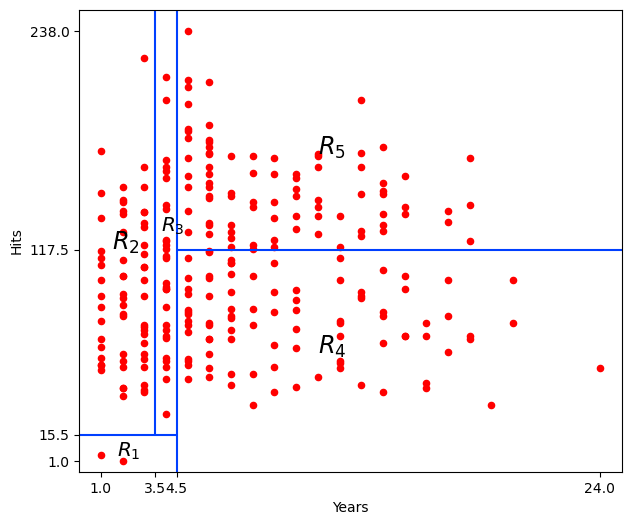

* Using Scikit-Learn's built-in `plot_tree()` method, reproduce the decision tree below.
* `export_graphiviz` is usually a better option for visualization.

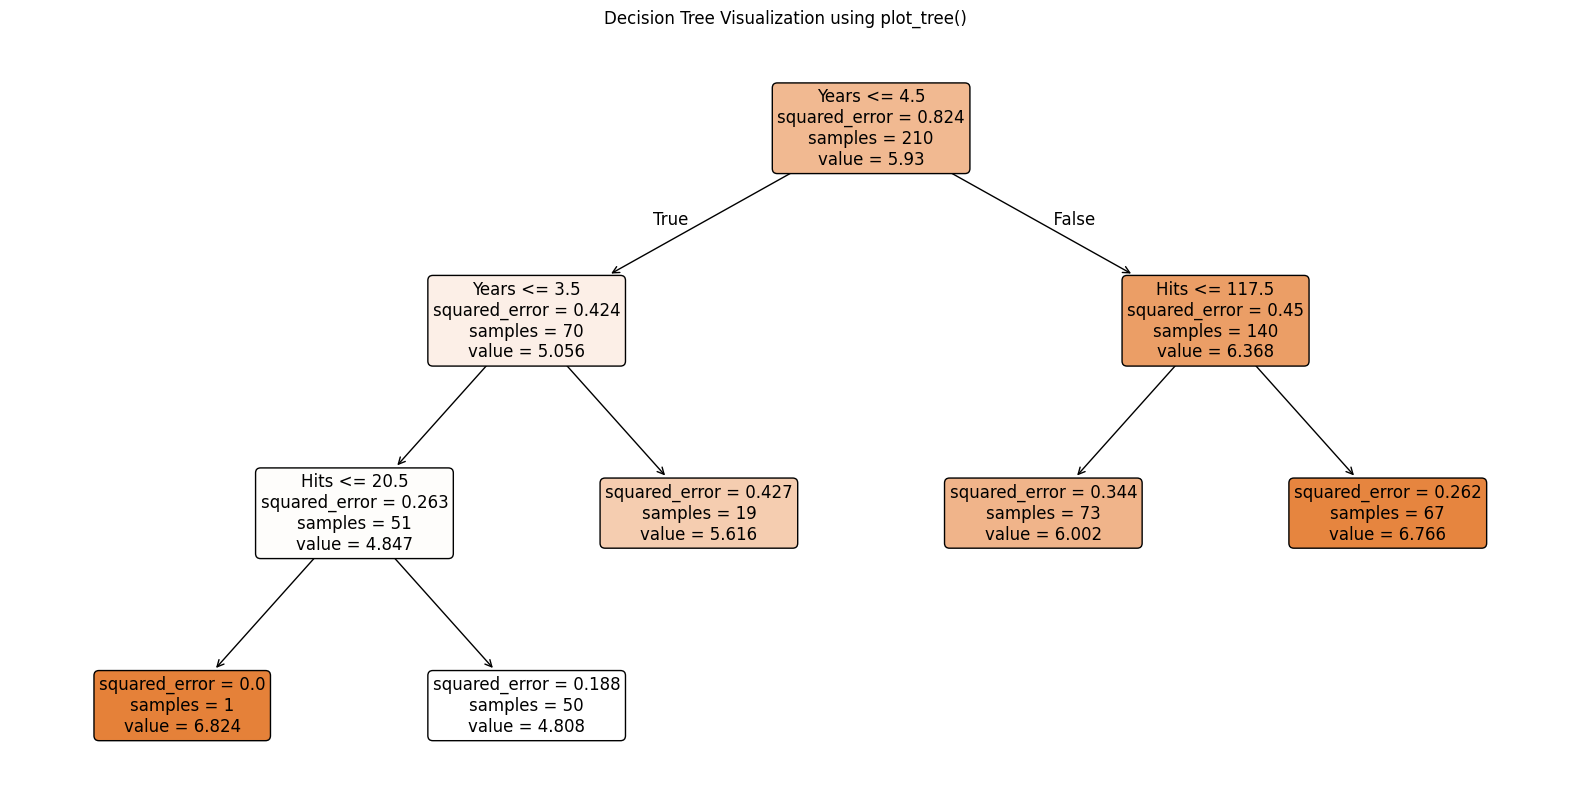

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Adjust size as needed

plot_tree(tree_regressor, 
          feature_names=['Years', 'Hits'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.title("Decision Tree Visualization using plot_tree()")
plt.show()

[Text(0.5, 0.875, 'x[0] <= 4.5\nsquared_error = 0.788\nsamples = 263\nvalue = 5.927'),
 Text(0.25, 0.625, 'x[1] <= 15.5\nsquared_error = 0.471\nsamples = 90\nvalue = 5.107'),
 Text(0.125, 0.375, 'squared_error = 0.176\nsamples = 2\nvalue = 7.243'),
 Text(0.375, 0.375, 'x[0] <= 3.5\nsquared_error = 0.371\nsamples = 88\nvalue = 5.058'),
 Text(0.25, 0.125, 'squared_error = 0.187\nsamples = 60\nvalue = 4.813'),
 Text(0.5, 0.125, 'squared_error = 0.362\nsamples = 28\nvalue = 5.583'),
 Text(0.75, 0.625, 'x[1] <= 117.5\nsquared_error = 0.42\nsamples = 173\nvalue = 6.354'),
 Text(0.625, 0.375, 'squared_error = 0.312\nsamples = 90\nvalue = 5.998'),
 Text(0.875, 0.375, 'squared_error = 0.252\nsamples = 83\nvalue = 6.74')]

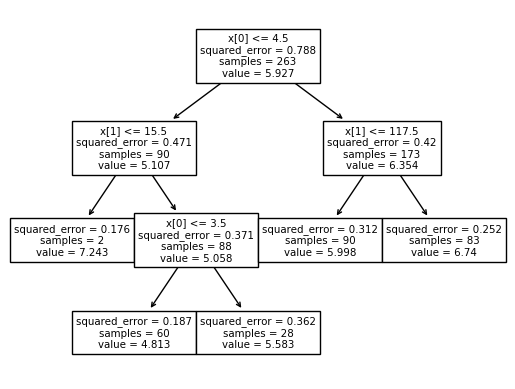

## **Cost-complexity pruning**
We will now try to find the optimal tree using **cost_complexity pruning**
1. Split the data into a training set and a testing set (technically, this is for validation). Use `test_size=0.3`, and `random_state=42`.
   * What are the sizes of the training and testing feature sets?
2. Train a full-sized Decision Tree using all the available data.
3. Once again, visualize the tree using `export_graphviz.`
4. Does it look like this tree is overfitting to $\mathcal{D}_{train}$? If yes, what suggests this? If no, why not?

Training feature set size: (225, 2)
Testing feature set size: (97, 2)


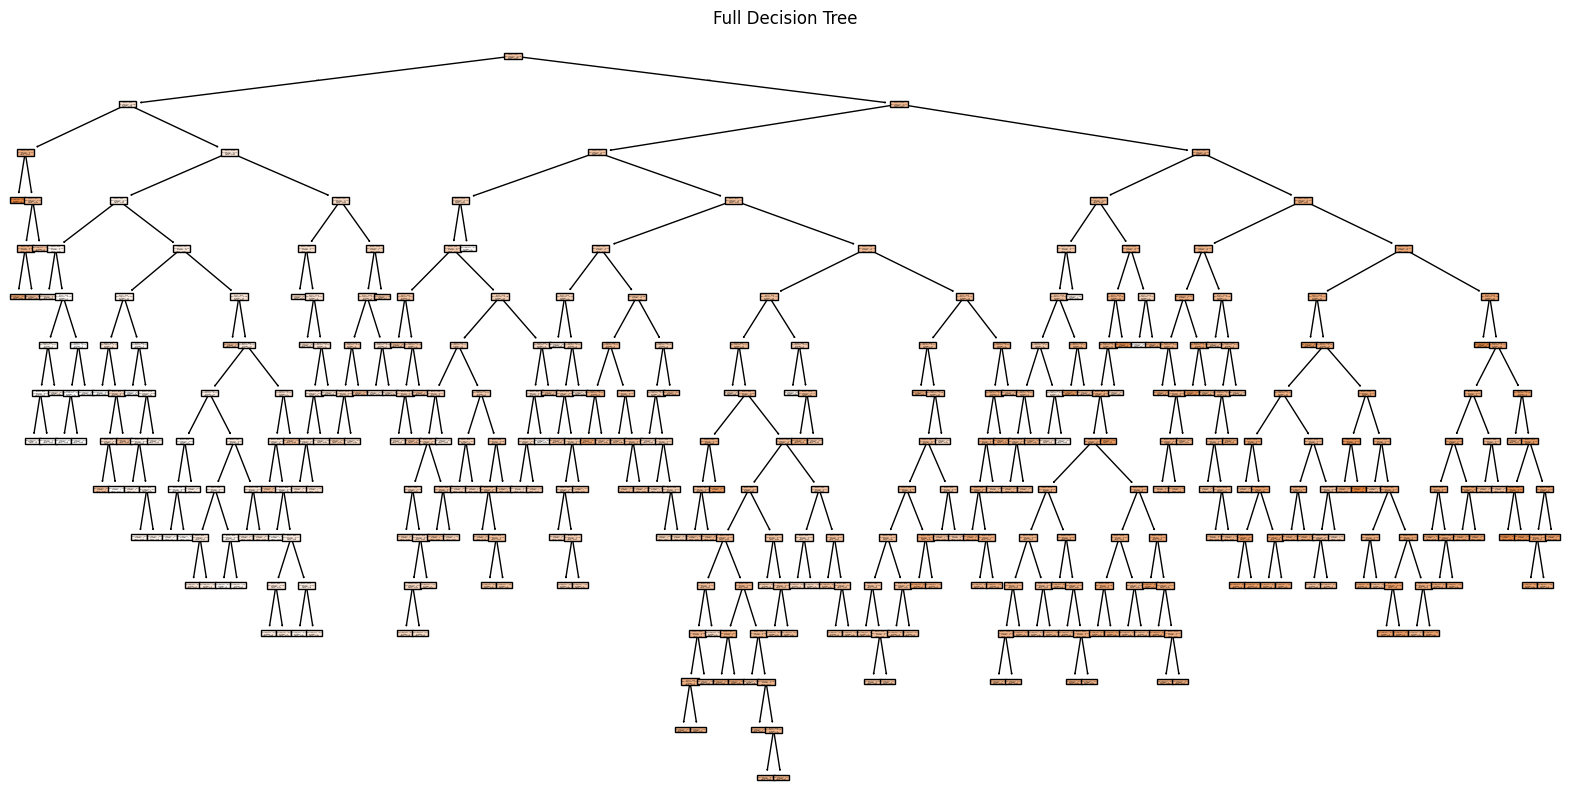

Training R^2: 0.9838
Testing R^2: 0.0585


In [23]:
# Replace missing values with column medians
df['log_salary'] = df['log_salary'].fillna(df['log_salary'].median())
X = df[['Years', 'Hits']]
y = df['log_salary']

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training feature set size: {X_train.shape}")
print(f"Testing feature set size: {X_test.shape}")

# 2. Train a full decision tree
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)

# 3. Visualize the tree using export_graphviz (requires Graphviz installed and on PATH)
dot_data = export_graphviz(
    full_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("full_tree", format='png', cleanup=True)

# Alternatively, display the tree using matplotlib
plt.figure(figsize=(20, 10))
plot_tree(full_tree, feature_names=X.columns, filled=True)
plt.title("Full Decision Tree")
plt.show()

# 4. Check for overfitting
train_score = full_tree.score(X_train, y_train)
test_score = full_tree.score(X_test, y_test)
print(f"Training R^2: {train_score:.4f}")
print(f"Testing R^2: {test_score:.4f}")

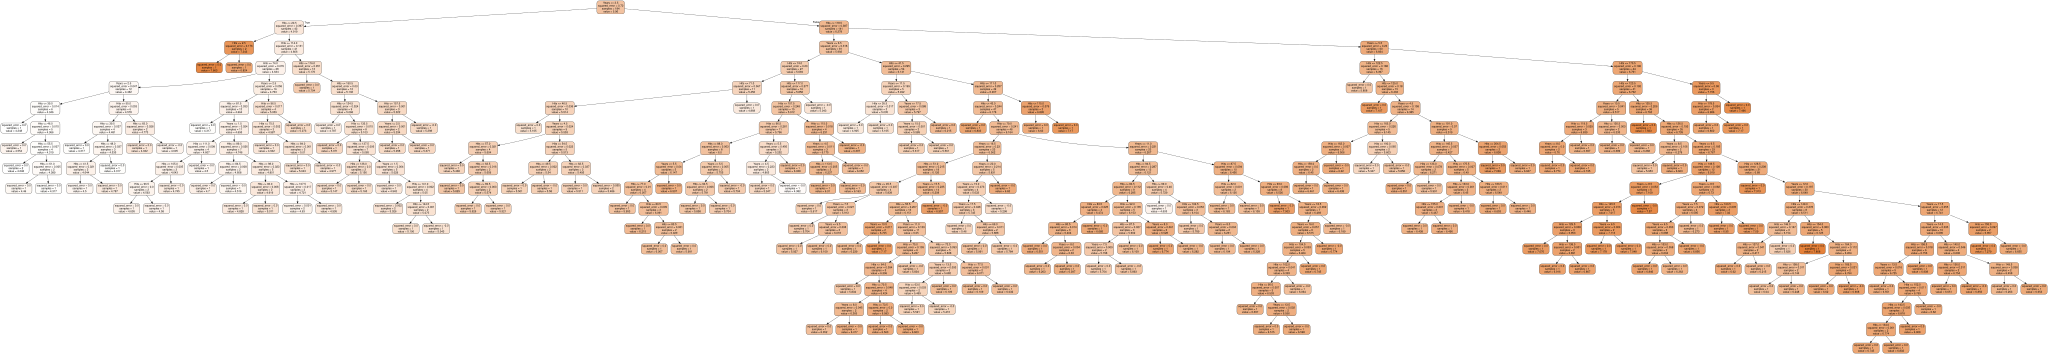

## **Regularized Loss**
We will now find the optimal tree using the **regularized loss**: $R_{\alpha}(T) = R(T)+\alpha |T|$
1. Your full-sized tree has an associated method named `cost_complexity_pruning_path()`. What does this method do?
2. Use the `ccp_alphas` attribute to create a list called `ccp_alphas` containing values of the regularization coefficient. What is the size of you list of the regularization coefficients?
3. Running `cost_complexity_pruning_path()` also gives the total leaf impurity in tree $T_{\alpha}$. Generate the total leaf impurity vs $\alpha$. Your plot should look like the one below.
4. Explain the trend of this plot.

Number of regularization coefficients: 139


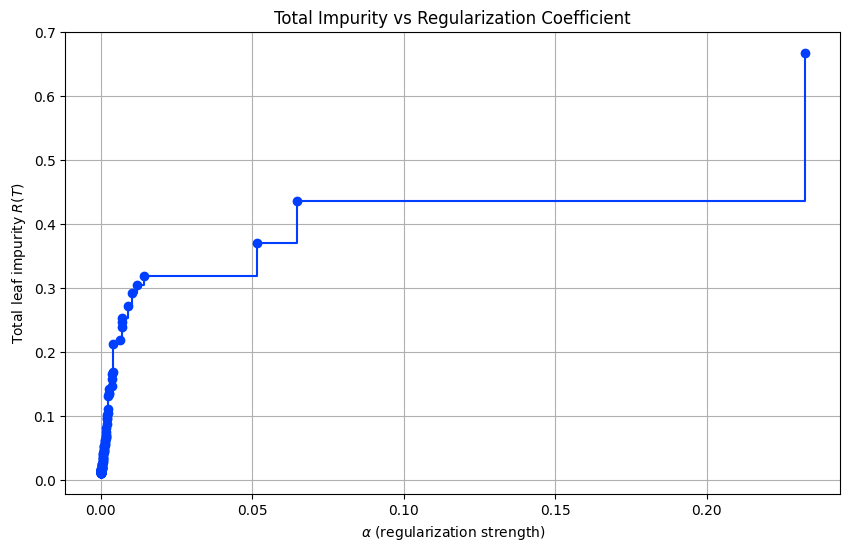


Explanation:
As alpha (𝛼) increases, the penalty for having more leaves becomes stronger.
This forces the tree to prune more aggressively — reducing the number of leaves to minimize the regularized loss.
Therefore, as alpha increases, the total impurity R(T) usually increases since the tree is simpler and can't fit the training data as well.
The curve tends to increase sharply after a certain alpha, suggesting aggressive pruning starts hurting performance.



In [24]:
# Step 1: Train full tree and get pruning path
full_tree = DecisionTreeRegressor(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)

# Step 2: Extract alphas and impurities
ccp_alphas = path.ccp_alphas 
impurities = path.impurities 

print(f"Number of regularization coefficients: {len(ccp_alphas)}")

# Step 3: Plot impurity vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel(r'$\alpha$ (regularization strength)')
plt.ylabel('Total leaf impurity $R(T)$')
plt.title('Total Impurity vs Regularization Coefficient')
plt.grid(True)
plt.show()

# Step 4: Explanation of the trend
print("""
Explanation:
As alpha (𝛼) increases, the penalty for having more leaves becomes stronger.
This forces the tree to prune more aggressively — reducing the number of leaves to minimize the regularized loss.
Therefore, as alpha increases, the total impurity R(T) usually increases since the tree is simpler and can't fit the training data as well.
The curve tends to increase sharply after a certain alpha, suggesting aggressive pruning starts hurting performance.
""")

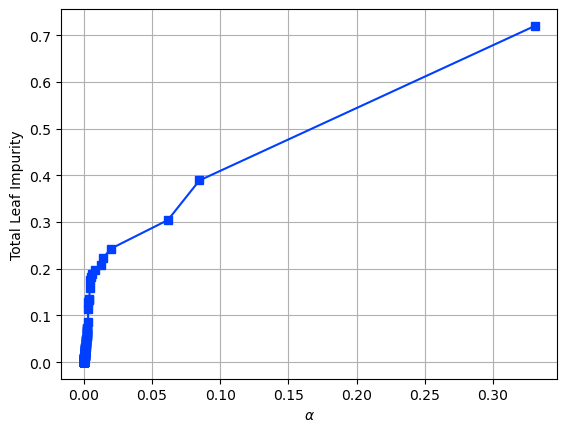

1. For each value of $\alpha$ in the list `ccp_alphas` train a decision tree regressor. Store all the trees in a list.
2. How many nodes does the last tree have? What value of $\alpha$ does this correspond to?

In [25]:
# Step 1: Train a decision tree regressor for each value of alpha in ccp_alphas
trees = []
for alpha in ccp_alphas:
    tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    trees.append(tree)

# Step 2: Find the number of nodes in the last tree and the corresponding alpha
last_tree = trees[-1]
num_nodes_last_tree = last_tree.tree_.node_count
alpha_last_tree = ccp_alphas[-1]

print(f"Number of nodes in the last tree: {num_nodes_last_tree}")
print(f"Alpha value for the last tree: {alpha_last_tree}")

Number of nodes in the last tree: 1
Alpha value for the last tree: 0.23243208053483344


* Use the `score()` method associated with your trees to generate two lists: train and test accuracy for each value of $\alpha.$
* Plot train and test accuracy vs $\alpha.$
* Which value of $\alpha$ would you choose? Why?

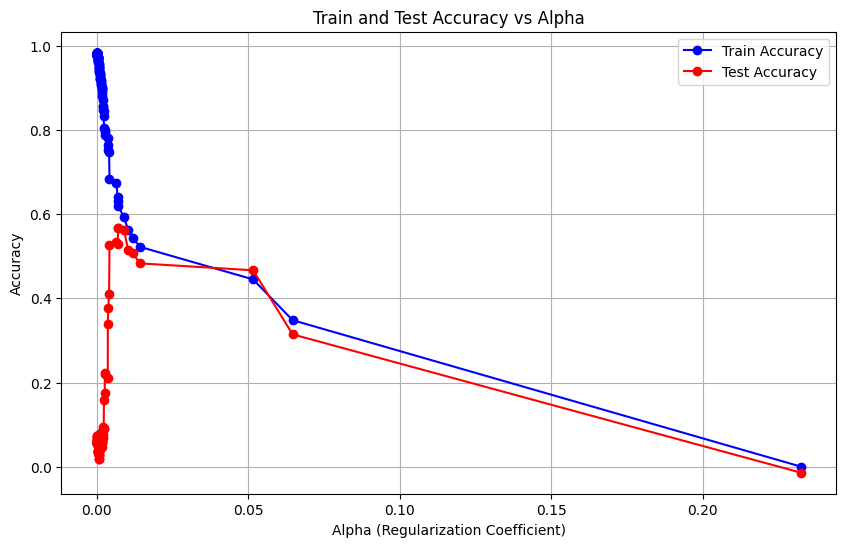

The optimal alpha value is: 0.007177240932726571


In [26]:
import matplotlib.pyplot as plt

# Step 1: Generate train and test accuracy for each value of alpha
train_accuracies = []
test_accuracies = []

for tree in trees:
    # Calculate training and testing accuracy for each tree
    train_accuracy = tree.score(X_train, y_train)
    test_accuracy = tree.score(X_test, y_test)
    
    # Append to the lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

# Step 2: Plot train and test accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_accuracies, label='Train Accuracy', color='blue', marker='o')
plt.plot(ccp_alphas, test_accuracies, label='Test Accuracy', color='red', marker='o')
plt.xlabel('Alpha (Regularization Coefficient)')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy vs Alpha')
plt.legend()
plt.grid(True)
plt.show()

# Step 3: Choose the optimal alpha
# Look for the alpha that gives a good trade-off between training and test accuracy
optimal_alpha = ccp_alphas[test_accuracies.index(max(test_accuracies))]
print(f"The optimal alpha value is: {optimal_alpha}")


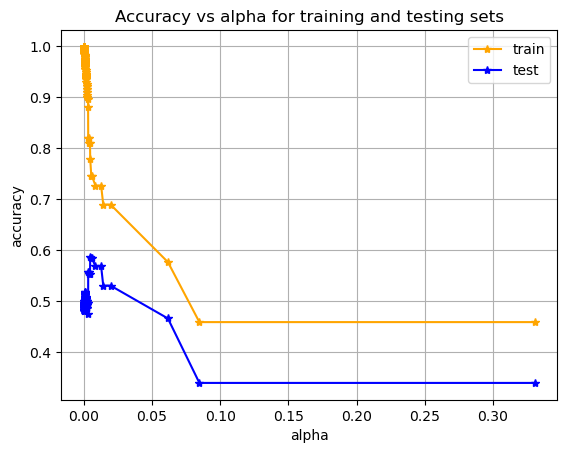

* Let's call this value $\alpha^*.$ How many leaves does $T_{\alpha^*}$ have?
* Draw $T_{\alpha^*}$
* What is the reduction in the number of leaves in the full tree versus the optimal regularized tree?

In [27]:
# Step 1: Determine the number of leaves in T_alpha_star (tree with optimal alpha)
# Find the index of the optimal alpha
optimal_tree = trees[test_accuracies.index(max(test_accuracies))]

# Get the number of leaves in the tree corresponding to alpha_star
num_leaves_alpha_star = optimal_tree.get_n_leaves()

# Step 2: Draw T_alpha_star
from sklearn.tree import export_graphviz
import graphviz

# Export the tree to DOT format
dot_data = export_graphviz(optimal_tree, out_file=None, 
                           feature_names=['Years', 'Hits'], 
                           filled=True, rounded=True, 
                           special_characters=True)

# Create a Graphviz Source object for visualization
graph = graphviz.Source(dot_data)
graph.render("optimal_tree", format='png', cleanup=True)

# Display the tree inline in the notebook
from IPython.display import Image
Image(filename="optimal_tree.png")

# Step 3: Calculate the reduction in the number of leaves
# Get the number of leaves in the full tree (before pruning)
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)
num_leaves_full_tree = full_tree.get_n_leaves()

# Calculate the reduction in the number of leaves
reduction_in_leaves = num_leaves_full_tree - num_leaves_alpha_star

print(f"Number of leaves in T_alpha_star: {num_leaves_alpha_star}")
print(f"Number of leaves in the full tree: {num_leaves_full_tree}")
print(f"Reduction in the number of leaves: {reduction_in_leaves}")

Number of leaves in T_alpha_star: 10
Number of leaves in the full tree: 206
Reduction in the number of leaves: 196


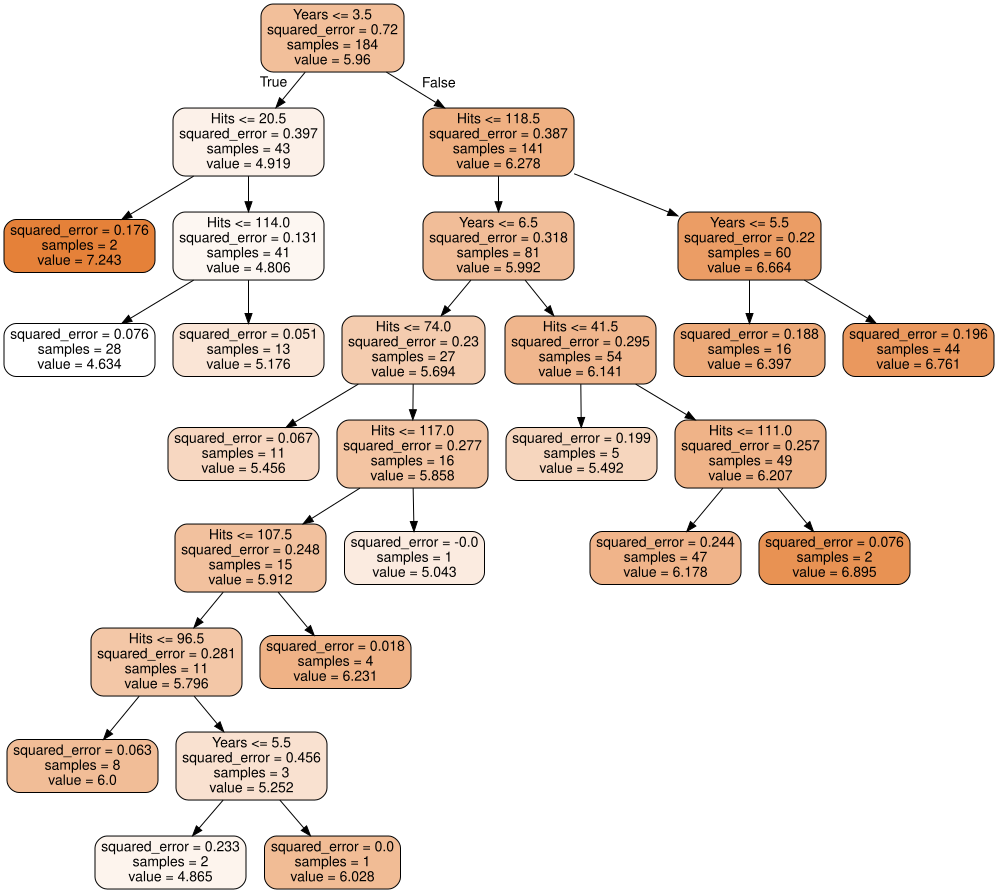

---

---